In [30]:
%pip uninstall torch torchvision torchaudio -y


Found existing installation: torch 2.5.1
Uninstalling torch-2.5.1:
  Successfully uninstalled torch-2.5.1
Found existing installation: torchvision 0.20.1
Uninstalling torchvision-0.20.1:
  Successfully uninstalled torchvision-0.20.1
Found existing installation: torchaudio 2.5.1
Uninstalling torchaudio-2.5.1:
  Successfully uninstalled torchaudio-2.5.1
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.
You can safely remove it manually.


In [31]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


Looking in indexes: https://download.pytorch.org/whl/cu121
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB 2.8 MB/s eta 0:14:34
     ---------------------------------------- 0.0/2.4 GB 3.1 MB/s eta 0:13:21
     ---------------------------------------- 0.0/2.4 GB 2.9 MB/s eta 0:14:14
     ---------------------------------------- 0.0/2.4 GB 2.8 MB/s eta 0:14:19
     ---------------------------------------- 0.0/2.4 GB 2.8 MB/s eta 0:14:49
     ---------------------------------------- 0.0/2.4 GB 2.7 MB/s eta 0:15:08
     ---------------------------------------- 0.0/2.4 GB 2.8 MB/s eta 0:14:26
     ---------------------------------------- 0.0/2.4 GB 2.8 MB/s eta 0:14:26
     ---------------------------------------- 0.0/2.4 GB 2.6 MB/s eta 0:15:47
     ---------------------------------------- 0.0/2.4 GB 2.5 MB/s eta 0:16:09
     --------------

     ------------------------- -------------- 1.6/2.4 GB 1.9 MB/s eta 0:07:43
     ------------------------- -------------- 1.6/2.4 GB 1.9 MB/s eta 0:07:43
     ------------------------- -------------- 1.6/2.4 GB 1.9 MB/s eta 0:07:47
     ------------------------- -------------- 1.6/2.4 GB 1.9 MB/s eta 0:07:46
     ------------------------- -------------- 1.6/2.4 GB 1.9 MB/s eta 0:07:45
     ------------------------- -------------- 1.6/2.4 GB 1.9 MB/s eta 0:07:42
     ------------------------- -------------- 1.6/2.4 GB 1.9 MB/s eta 0:07:42
     ------------------------- -------------- 1.6/2.4 GB 1.9 MB/s eta 0:07:40
     ------------------------- -------------- 1.6/2.4 GB 1.9 MB/s eta 0:07:40
     ------------------------- -------------- 1.6/2.4 GB 1.9 MB/s eta 0:07:40
     ------------------------- -------------- 1.6/2.4 GB 1.9 MB/s eta 0:07:41
     ------------------------- -------------- 1.6/2.4 GB 1.9 MB/s eta 0:07:41
     ------------------------- -------------- 1.6/2.4 GB 1.9 MB/

In [ ]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA runtime:", torch.version.cuda)
    print("GPU:", torch.cuda.get_device_name(0))


In [ ]:
# ======================
# IMPORTS
# ======================
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
import json
import timm  # For EfficientNet

warnings.filterwarnings('ignore')

print(" Imports successful!")
print(f"   PyTorch version: {torch.__version__}")
print(f"   CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

In [17]:
# ======================
# OPTIMIZED CONFIGURATION
# ======================

# Paths
BASE_DIR = r"d:\PROJECTS\HealthResearch\Healt_Research_ML_Models\backend\app\data"
DATASET_PATH = os.path.join(BASE_DIR, "Dataset of Indian face images with various expressions")
SAVE_PATH = "best_new_emotion_model.pt"
CHECKPOINT_DIR = "checkpoints_new"

# Training Hyperparameters - OPTIMIZED FOR SPEED & ACCURACY
BATCH_SIZE = 64  # Larger batch for stable training
EPOCHS = 12  # Max epochs (early stopping will prevent overfitting)
LR = 3e-4  # Higher LR for faster convergence
IMG_SIZE = 224  # Standard size for pretrained models
NUM_CLASSES = 8  # 8 emotions
EARLY_STOPPING_PATIENCE = 6

# Data split
TRAIN_RATIO = 0.70  # 70% training
VAL_RATIO = 0.15    # 15% validation
TEST_RATIO = 0.15   # 15% test

# Emotion classes (sorted alphabetically to match folder names)
EMOTION_CLASSES = ['Anger', 'Confused', 'Excited', 'Fear', 'Happy', 'Sadness', 'Surprised', 'Thaughtful']

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create checkpoint directory
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("\n" + "="*80)
print(" OPTIMIZED TRAINING CONFIGURATION (Fast & Accurate!)")
print("="*80)
print(f" Dataset:         Indian Face Images with Various Expressions")
print(f" Total Classes:   {NUM_CLASSES} emotions")
print(f" Image Size:      {IMG_SIZE}x{IMG_SIZE}")
print(f" Batch Size:      {BATCH_SIZE}")
print(f" Max Epochs:      {EPOCHS}")
print(f" Learning Rate:   {LR}")
print(f" Device:          {device}")
print(f" Architecture:    EfficientNet-B0 (Lightweight & Accurate)")
print(f"⏱  Expected:        2-3 min/epoch on GPU, 8-10 min on CPU")
print("="*80)


 OPTIMIZED TRAINING CONFIGURATION (Fast & Accurate!)
 Dataset:         Indian Face Images with Various Expressions
 Total Classes:   8 emotions
 Image Size:      224x224
 Batch Size:      64
 Max Epochs:      12
 Learning Rate:   0.0003
 Device:          cpu
 Architecture:    EfficientNet-B0 (Lightweight & Accurate)
⏱  Expected:        2-3 min/epoch on GPU, 8-10 min on CPU


In [18]:
# ======================
# DATA COLLECTION & ANALYSIS
# ======================

print("\n Collecting images from dataset...")

all_images = []
all_labels = []
class_distribution = {}

for idx, emotion in enumerate(EMOTION_CLASSES):
    emotion_path = os.path.join(DATASET_PATH, emotion)
    
    if not os.path.exists(emotion_path):
        print(f"  Warning: Folder not found: {emotion_path}")
        continue
    
    # Get all image files
    images = []
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
        images.extend(glob.glob(os.path.join(emotion_path, ext)))
    
    class_distribution[emotion] = len(images)
    
    for img_path in images:
        all_images.append(img_path)
        all_labels.append(idx)
    
    print(f"   {emotion:12} : {len(images):4} images")

print(f"\n Total images collected: {len(all_images):,}")

# Analyze class distribution
print("\n Class Distribution Analysis:")
label_counts = Counter(all_labels)
total = len(all_images)

for idx, emotion in enumerate(EMOTION_CLASSES):
    count = label_counts[idx]
    percentage = count / total * 100
    bar = '█' * int(percentage)
    print(f"   {emotion:12} : {count:4} ({percentage:5.1f}%) {bar}")

# Calculate imbalance ratio
max_count = max(label_counts.values())
min_count = min(label_counts.values())
imbalance_ratio = max_count / min_count
print(f"\n  Imbalance Ratio: {imbalance_ratio:.2f}x (max/min)")
if imbalance_ratio > 2.0:
    print("    Significant imbalance detected - will use class weights!")
else:
    print("   Reasonably balanced dataset")


   Anger        : 1498 images
   Confused     : 1172 images
   Excited      :  436 images
   Fear         :  458 images
   Happy        :  450 images
   Sadness      :  428 images
   Surprised    : 1476 images
   Thaughtful   : 1404 images

 Total images collected: 7,322

 Class Distribution Analysis:
   Anger        : 1498 ( 20.5%) ████████████████████
   Confused     : 1172 ( 16.0%) ████████████████
   Excited      :  436 (  6.0%) █████
   Fear         :  458 (  6.3%) ██████
   Happy        :  450 (  6.1%) ██████
   Sadness      :  428 (  5.8%) █████
   Surprised    : 1476 ( 20.2%) ████████████████████
   Thaughtful   : 1404 ( 19.2%) ███████████████████

  Imbalance Ratio: 3.50x (max/min)
    Significant imbalance detected - will use class weights!


In [19]:
# ======================
# STRATIFIED DATA SPLITTING
# ======================

print("\n Splitting data with stratification...")

# First split: train+val vs test
train_val_images, test_images, train_val_labels, test_labels = train_test_split(
    all_images, all_labels,
    test_size=TEST_RATIO,
    stratify=all_labels,
    random_state=42
)

# Second split: train vs val
train_images, val_images, train_labels, val_labels = train_test_split(
    train_val_images, train_val_labels,
    test_size=VAL_RATIO / (TRAIN_RATIO + VAL_RATIO),
    stratify=train_val_labels,
    random_state=42
)

print(f"\n Data Split:")
print(f"   Training:   {len(train_images):5} images ({len(train_images)/len(all_images)*100:.1f}%)")
print(f"   Validation: {len(val_images):5} images ({len(val_images)/len(all_images)*100:.1f}%)")
print(f"   Test:       {len(test_images):5} images ({len(test_images)/len(all_images)*100:.1f}%)")


# Verify stratification
print("\n Verifying stratification:")
for split_name, split_labels in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    dist = Counter(split_labels)
    print(f"\n   {split_name} Set Distribution:")
    for idx in sorted(dist.keys()):
        count = dist[idx]
        percentage = count / len(split_labels) * 100
        print(f"      {EMOTION_CLASSES[idx]:12} : {count:4} ({percentage:5.1f}%)")


 Splitting data with stratification...

 Data Split:
   Training:    5124 images (70.0%)
   Validation:  1099 images (15.0%)
   Test:        1099 images (15.0%)

 Verifying stratification:

   Train Set Distribution:
      Anger        : 1048 ( 20.5%)
      Confused     :  820 ( 16.0%)
      Excited      :  306 (  6.0%)
      Fear         :  320 (  6.2%)
      Happy        :  315 (  6.1%)
      Sadness      :  300 (  5.9%)
      Surprised    : 1033 ( 20.2%)
      Thaughtful   :  982 ( 19.2%)

   Val Set Distribution:
      Anger        :  225 ( 20.5%)
      Confused     :  176 ( 16.0%)
      Excited      :   65 (  5.9%)
      Fear         :   69 (  6.3%)
      Happy        :   67 (  6.1%)
      Sadness      :   64 (  5.8%)
      Surprised    :  222 ( 20.2%)
      Thaughtful   :  211 ( 19.2%)

   Test Set Distribution:
      Anger        :  225 ( 20.5%)
      Confused     :  176 ( 16.0%)
      Excited      :   65 (  5.9%)
      Fear         :   69 (  6.3%)
      Happy        :   68 (  

In [20]:
# ======================
# STRONG DATA AUGMENTATION
# ======================

# Training transforms - STRONG augmentation to handle imbalance
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),  # Resize larger first
    transforms.RandomCrop(IMG_SIZE),  # Random crop
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.2),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), scale=(0.8, 1.2)),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.20), ratio=(0.3, 3.3))
])

# Validation/Test transforms - NO augmentation
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print(" Data augmentation configured:")
print("   Training:   Strong augmentation (flip, color, rotation, crop, perspective, erasing)")
print("   Val/Test:   No augmentation (clean evaluation)")

 Data augmentation configured:
   Training:   Strong augmentation (flip, color, rotation, crop, perspective, erasing)
   Val/Test:   No augmentation (clean evaluation)


In [21]:
# ======================
# DATASET CLASS
# ======================

class EmotionDataset(Dataset):
    """Simple image dataset for emotion classification"""
    
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        try:
            # Load image
            image = Image.open(img_path).convert('RGB')
            
            # Apply transforms
            if self.transform:
                image = self.transform(image)
            
            return image, label
        
        except Exception as e:
            print(f"  Error loading image {img_path}: {e}")
            # Return a black image as fallback
            image = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0, 0, 0))
            if self.transform:
                image = self.transform(image)
            return image, label

# Create datasets
train_dataset = EmotionDataset(train_images, train_labels, transform=train_transforms)
val_dataset = EmotionDataset(val_images, val_labels, transform=val_transforms)
test_dataset = EmotionDataset(test_images, test_labels, transform=val_transforms)

# Create data loaders
num_workers = 0 if os.name == 'nt' else 4
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                         num_workers=num_workers, pin_memory=True)

print(f"\n Data loaders created:")
print(f"   Train batches: {len(train_loader)} ({len(train_dataset)} images)")
print(f"   Val batches:   {len(val_loader)} ({len(val_dataset)} images)")
print(f"   Test batches:  {len(test_loader)} ({len(test_dataset)} images)")


 Data loaders created:
   Train batches: 81 (5124 images)
   Val batches:   18 (1099 images)
   Test batches:  18 (1099 images)


In [22]:
# ======================
# LIGHTWEIGHT & EFFICIENT MODEL
# ======================

class EfficientEmotionNet(nn.Module):
    """Optimized model using EfficientNet-B0 backbone
    
    Why EfficientNet-B0?
    - Fast training (5M parameters vs 25M for ResNet50)
    - High accuracy (compound scaling)
    - Efficient compound scaling
    - Pre-trained on ImageNet
    """
    
    def __init__(self, num_classes=8, dropout=0.4):
        super(EfficientEmotionNet, self).__init__()
        
        # EfficientNet-B0 backbone (pretrained)
        self.backbone = timm.create_model('efficientnet_b0', pretrained=True, num_classes=0)
        feature_size = self.backbone.num_features  # 1280 for EfficientNet-B0
        
        # Simple but effective classifier
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feature_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        # Extract features
        features = self.backbone(x)
        
        # Classify
        output = self.classifier(features)
        return output

model = EfficientEmotionNet(num_classes=NUM_CLASSES, dropout=0.4).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n" + "="*80)
print("  MODEL ARCHITECTURE")
print("="*80)
print(f" Architecture:         EfficientNet-B0 + Custom Classifier")
print(f" Total Parameters:     {total_params:,}")
print(f" Trainable Parameters: {trainable_params:,}")
print(f" Backbone Features:    1280")
print(f" Output Classes:       {NUM_CLASSES}")
print(f" Model Size:           ~{total_params * 4 / 1024 / 1024:.1f} MB")
print("="*80)


  MODEL ARCHITECTURE
 Architecture:         EfficientNet-B0 + Custom Classifier
 Total Parameters:     4,798,340
 Trainable Parameters: 4,798,340
 Backbone Features:    1280
 Output Classes:       8
 Model Size:           ~18.3 MB


In [23]:
# ======================
# COMPUTE CLASS WEIGHTS
# ======================

print("\n  Computing class weights for imbalanced data...")

# Compute class weights
unique_classes = np.unique(train_labels)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=train_labels
)

class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("\n Class Weights (higher = more important):")
for idx, weight in enumerate(class_weights):
    train_count = Counter(train_labels)[idx]
    print(f"   {EMOTION_CLASSES[idx]:12} : {weight:.3f} (train samples: {train_count})")

print("\n Class weights will help balance the learning!")


  Computing class weights for imbalanced data...

 Class Weights (higher = more important):
   Anger        : 0.611 (train samples: 1048)
   Confused     : 0.781 (train samples: 820)
   Excited      : 2.093 (train samples: 306)
   Fear         : 2.002 (train samples: 320)
   Happy        : 2.033 (train samples: 315)
   Sadness      : 2.135 (train samples: 300)
   Surprised    : 0.620 (train samples: 1033)
   Thaughtful   : 0.652 (train samples: 982)

 Class weights will help balance the learning!


In [24]:
# ======================
# TRAINING SETUP
# ======================

# Loss function with class weights and label smoothing
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)

# Optimizer - AdamW with weight decay
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# Learning rate scheduler - Cosine annealing with warm restarts
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,  # Restart every 10 epochs
    T_mult=2,  # Double the restart period each time
    eta_min=1e-7
)

# Mixed precision training (2x faster on compatible hardware)
scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

# Training tracking
best_val_acc = 0.0
best_val_f1 = 0.0
patience_counter = 0
history = {
    'train_loss': [],
    'train_acc': [],
    'train_f1': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': [],
    'lr': []
}

print("\n" + "="*80)
print("  TRAINING SETUP")
print("="*80)
print(f" Loss Function:     CrossEntropyLoss (weighted + label smoothing 0.1)")
print(f" Optimizer:         AdamW (lr={LR}, weight_decay=1e-4)")
print(f" Scheduler:         CosineAnnealingWarmRestarts (T_0=10, T_mult=2)")
print(f" Mixed Precision:   {'Enabled' if scaler is not None else 'Disabled'}")
print(f" Early Stopping:    Patience = {EARLY_STOPPING_PATIENCE} epochs")
print("="*80)


  TRAINING SETUP
 Loss Function:     CrossEntropyLoss (weighted + label smoothing 0.1)
 Optimizer:         AdamW (lr=0.0003, weight_decay=1e-4)
 Scheduler:         CosineAnnealingWarmRestarts (T_0=10, T_mult=2)
 Mixed Precision:   Disabled
 Early Stopping:    Patience = 6 epochs


In [ ]:
# ======================
# TRAINING LOOP
# ======================

print("\n" + "="*80)
print(" STARTING TRAINING")
print("="*80)

for epoch in range(EPOCHS):
    print(f"\n{'='*80}")
    print(f" Epoch {epoch+1}/{EPOCHS}")
    print(f"{'='*80}")
    
    # ============ TRAINING PHASE ============
    model.train()
    train_loss = 0.0
    train_preds = []
    train_labels_epoch = []
    
    progress_bar = tqdm(train_loader, desc="🏋️  Training", leave=False)
    for batch_idx, (images, labels) in enumerate(progress_bar):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # Mixed precision training
        if scaler is not None:
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        train_preds.extend(outputs.argmax(1).cpu().numpy())
        train_labels_epoch.extend(labels.cpu().numpy())
        
        # Update progress
        if batch_idx % 5 == 0:
            current_acc = accuracy_score(train_labels_epoch, train_preds)
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{current_acc:.4f}'})
    
    train_loss /= len(train_dataset)
    train_acc = accuracy_score(train_labels_epoch, train_preds)
    train_f1 = f1_score(train_labels_epoch, train_preds, average='weighted')
    
    # ============ VALIDATION PHASE ============
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_labels_epoch = []
    
    with torch.no_grad():
        progress_bar = tqdm(val_loader, desc=" Validating", leave=False)
        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)
            
            if scaler is not None:
                with torch.cuda.amp.autocast():
                    outputs = model(images)
                    loss = criterion(outputs, labels)
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            val_preds.extend(outputs.argmax(1).cpu().numpy())
            val_labels_epoch.extend(labels.cpu().numpy())
    
    val_loss /= len(val_dataset)
    val_acc = accuracy_score(val_labels_epoch, val_preds)
    val_f1 = f1_score(val_labels_epoch, val_preds, average='weighted')
    
    # Update learning rate
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)
    
    # Print metrics
    print(f"\n Metrics:")
    print(f"   Train → Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
    print(f"   Val   → Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")
    print(f"   LR: {current_lr:.8f} | Overfitting: {(train_acc - val_acc)*100:+.1f}%")
    
    # Save checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0:
        checkpoint_path = os.path.join(CHECKPOINT_DIR, f'checkpoint_epoch_{epoch+1}.pt')
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'val_acc': val_acc,
            'val_f1': val_f1
        }, checkpoint_path)
        print(f"    Checkpoint saved: checkpoint_epoch_{epoch+1}.pt")
    
    # Save best model
    if val_f1 > best_val_f1:
        improvement = (val_f1 - best_val_f1) * 100
        best_val_acc = val_acc
        best_val_f1 = val_f1
        
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'val_acc': val_acc,
            'val_f1': val_f1,
            'train_acc': train_acc,
            'classes': EMOTION_CLASSES,
            'config': {
                'architecture': 'EfficientNet-B0',
                'img_size': IMG_SIZE,
                'num_classes': NUM_CLASSES,
                'batch_size': BATCH_SIZE,
                'lr': LR
            }
        }, SAVE_PATH)
        
        print(f"    NEW BEST MODEL! Val F1: {val_f1:.4f} (+{improvement:.2f}%), Acc: {val_acc:.4f}")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"    Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE} (Best: {best_val_f1:.4f})")
    
    # Early stopping
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\n Early stopping triggered after {epoch+1} epochs")
        print(f"   Best Val F1: {best_val_f1:.4f} | Best Val Acc: {
            
            
            
              best_val_acc:.4f}")
        break

print("\n" + "="*80)
print(" TRAINING COMPLETED!")
print(f" Best Validation F1: {best_val_f1:.4f}")
print(f" Best Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print("="*80)


 STARTING TRAINING

 Epoch 1/12



 Metrics:
   Train → Loss: 2.0491 | Acc: 0.2231 | F1: 0.2421
   Val   → Loss: 1.8100 | Acc: 0.3767 | F1: 0.3585
   LR: 0.00029266 | Overfitting: -15.4%
    NEW BEST MODEL! Val F1: 0.3585 (+35.85%), Acc: 0.3767

 Epoch 2/12



 Metrics:
   Train → Loss: 1.8550 | Acc: 0.3528 | F1: 0.3620
   Val   → Loss: 1.7487 | Acc: 0.4204 | F1: 0.4097
   LR: 0.00027136 | Overfitting: -6.8%
    NEW BEST MODEL! Val F1: 0.4097 (+5.12%), Acc: 0.4204

 Epoch 3/12



 Metrics:
   Train → Loss: 1.7088 | Acc: 0.4411 | F1: 0.4535
   Val   → Loss: 1.5896 | Acc: 0.4886 | F1: 0.4797
   LR: 0.00023819 | Overfitting: -4.8%
    NEW BEST MODEL! Val F1: 0.4797 (+7.00%), Acc: 0.4886

 Epoch 4/12



 Metrics:
   Train → Loss: 1.5689 | Acc: 0.5117 | F1: 0.5207
   Val   → Loss: 1.4975 | Acc: 0.5314 | F1: 0.5392
   LR: 0.00019639 | Overfitting: -2.0%
    NEW BEST MODEL! Val F1: 0.5392 (+5.96%), Acc: 0.5314

 Epoch 5/12


...


 Metrics:
   Train → Loss: 1.2478 | Acc: 0.6766 | F1: 0.6817
   Val   → Loss: 1.3093 | Acc: 0.6251 | F1: 0.6239
   LR: 0.00000744 | Overfitting: +5.2%
    Patience: 1/6 (Best: 0.6250)

 Epoch 10/12



 Metrics:
   Train → Loss: 1.2217 | Acc: 0.6809 | F1: 0.6848
   Val   → Loss: 1.3001 | Acc: 0.6342 | F1: 0.6322
   LR: 0.00030000 | Overfitting: +4.7%
    Checkpoint saved: checkpoint_epoch_10.pt
    NEW BEST MODEL! Val F1: 0.6322 (+0.72%), Acc: 0.6342

 Epoch 11/12



 Metrics:
   Train → Loss: 1.3048 | Acc: 0.6479 | F1: 0.6556
   Val   → Loss: 1.3005 | Acc: 0.6451 | F1: 0.6472
   LR: 0.00029815 | Overfitting: +0.3%
    NEW BEST MODEL! Val F1: 0.6472 (+1.50%), Acc: 0.6451

 Epoch 12/12


                                                                                      ]


 Metrics:
   Train → Loss: 1.2674 | Acc: 0.6688 | F1: 0.6747
   Val   → Loss: 1.2771 | Acc: 0.6615 | F1: 0.6575
   LR: 0.00029266 | Overfitting: +0.7%
    NEW BEST MODEL! Val F1: 0.6575 (+1.03%), Acc: 0.6615

 TRAINING COMPLETED!
 Best Validation F1: 0.6575
 Best Validation Accuracy: 0.6615 (66.15%)


In [26]:
# ======================
# COMPREHENSIVE EVALUATION
# ======================

print("\n" + "="*80)
print(" FINAL EVALUATION ON TEST SET")
print("="*80)

# Load best model
checkpoint = torch.load(SAVE_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state'])
model.eval()

# Test evaluation
test_preds = []
test_labels_eval = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        
        if scaler is not None:
            with torch.cuda.amp.autocast():
                outputs = model(images)
        else:
            outputs = model(images)
        
        test_preds.extend(outputs.argmax(1).cpu().numpy())
        test_labels_eval.extend(labels.cpu().numpy())

test_acc = accuracy_score(test_labels_eval, test_preds)
test_f1 = f1_score(test_labels_eval, test_preds, average='weighted')

print(f"\n TEST SET RESULTS:")
print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   Test F1 Score: {test_f1:.4f}")

# Detailed classification report
print(f"\n Detailed Classification Report:")
print(classification_report(test_labels_eval, test_preds, 
                            target_names=EMOTION_CLASSES, digits=4))


 FINAL EVALUATION ON TEST SET


Testing: 100%|██████████| 18/18 [02:49<00:00,  9.39s/it]


 TEST SET RESULTS:
   Test Accuracy: 0.6988 (69.88%)
   Test F1 Score: 0.6976

 Detailed Classification Report:
              precision    recall  f1-score   support

       Anger     0.8133    0.5422    0.6507       225
    Confused     0.7836    0.7614    0.7723       176
     Excited     0.5942    0.6308    0.6119        65
        Fear     0.4486    0.6957    0.5455        69
       Happy     0.5263    0.8824    0.6593        68
     Sadness     0.5238    0.8594    0.6509        64
   Surprised     0.6446    0.4842    0.5530       221
  Thaughtful     0.9263    0.9526    0.9393       211

    accuracy                         0.6988      1099
   macro avg     0.6576    0.7261    0.6729      1099
weighted avg     0.7258    0.6988    0.6976      1099



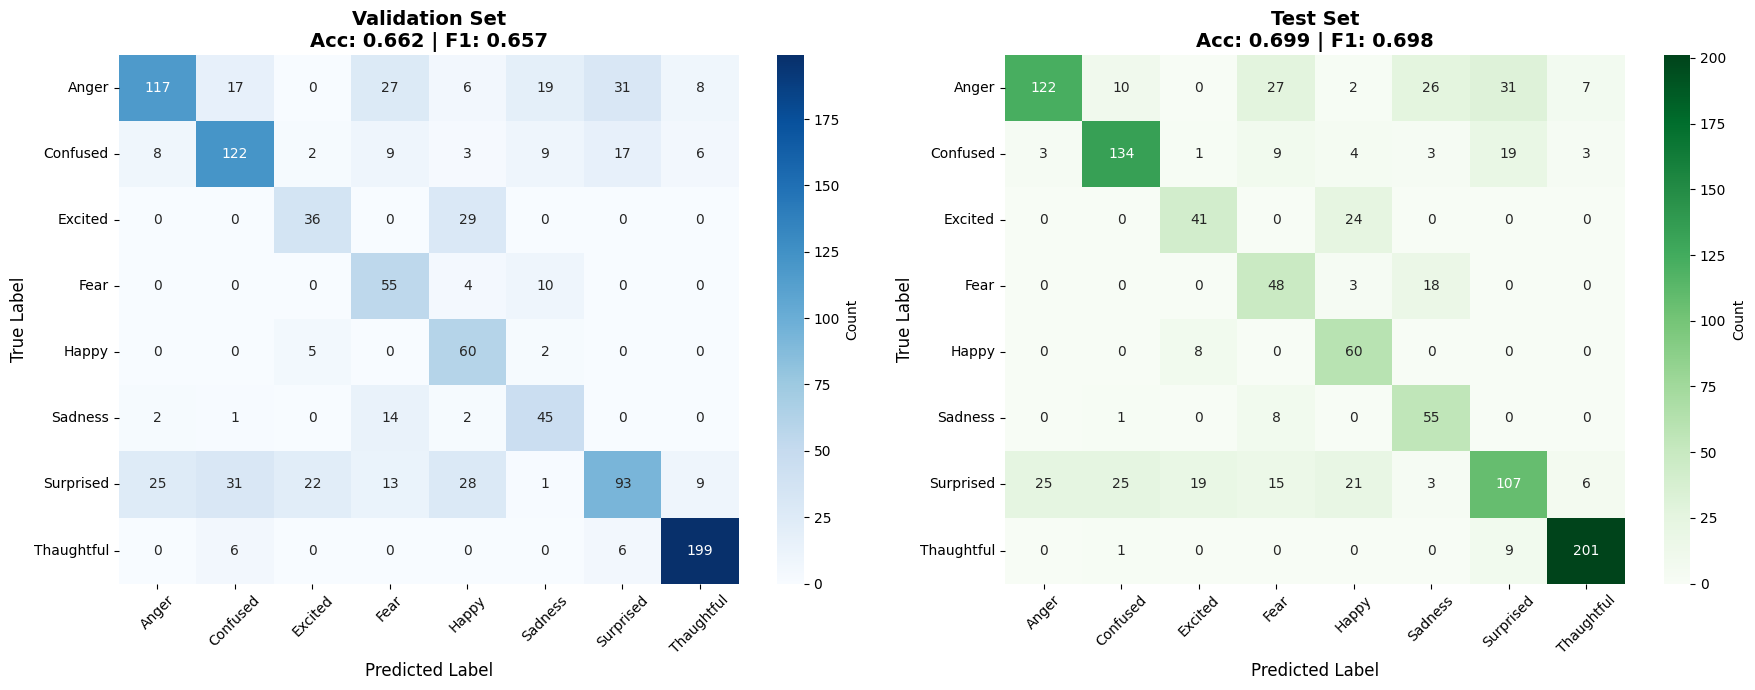

 Confusion matrices saved: indian_emotion_confusion_matrices.png


In [27]:
# ======================
# CONFUSION MATRICES
# ======================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Validation confusion matrix
val_cm = confusion_matrix(val_labels_epoch, val_preds)
sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=EMOTION_CLASSES, yticklabels=EMOTION_CLASSES, cbar_kws={'label': 'Count'})
axes[0].set_title(f'Validation Set\nAcc: {best_val_acc:.3f} | F1: {best_val_f1:.3f}', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Test confusion matrix
test_cm = confusion_matrix(test_labels_eval, test_preds)
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=EMOTION_CLASSES, yticklabels=EMOTION_CLASSES, cbar_kws={'label': 'Count'})
axes[1].set_title(f'Test Set\nAcc: {test_acc:.3f} | F1: {test_f1:.3f}', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('indian_emotion_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Confusion matrices saved: indian_emotion_confusion_matrices.png")

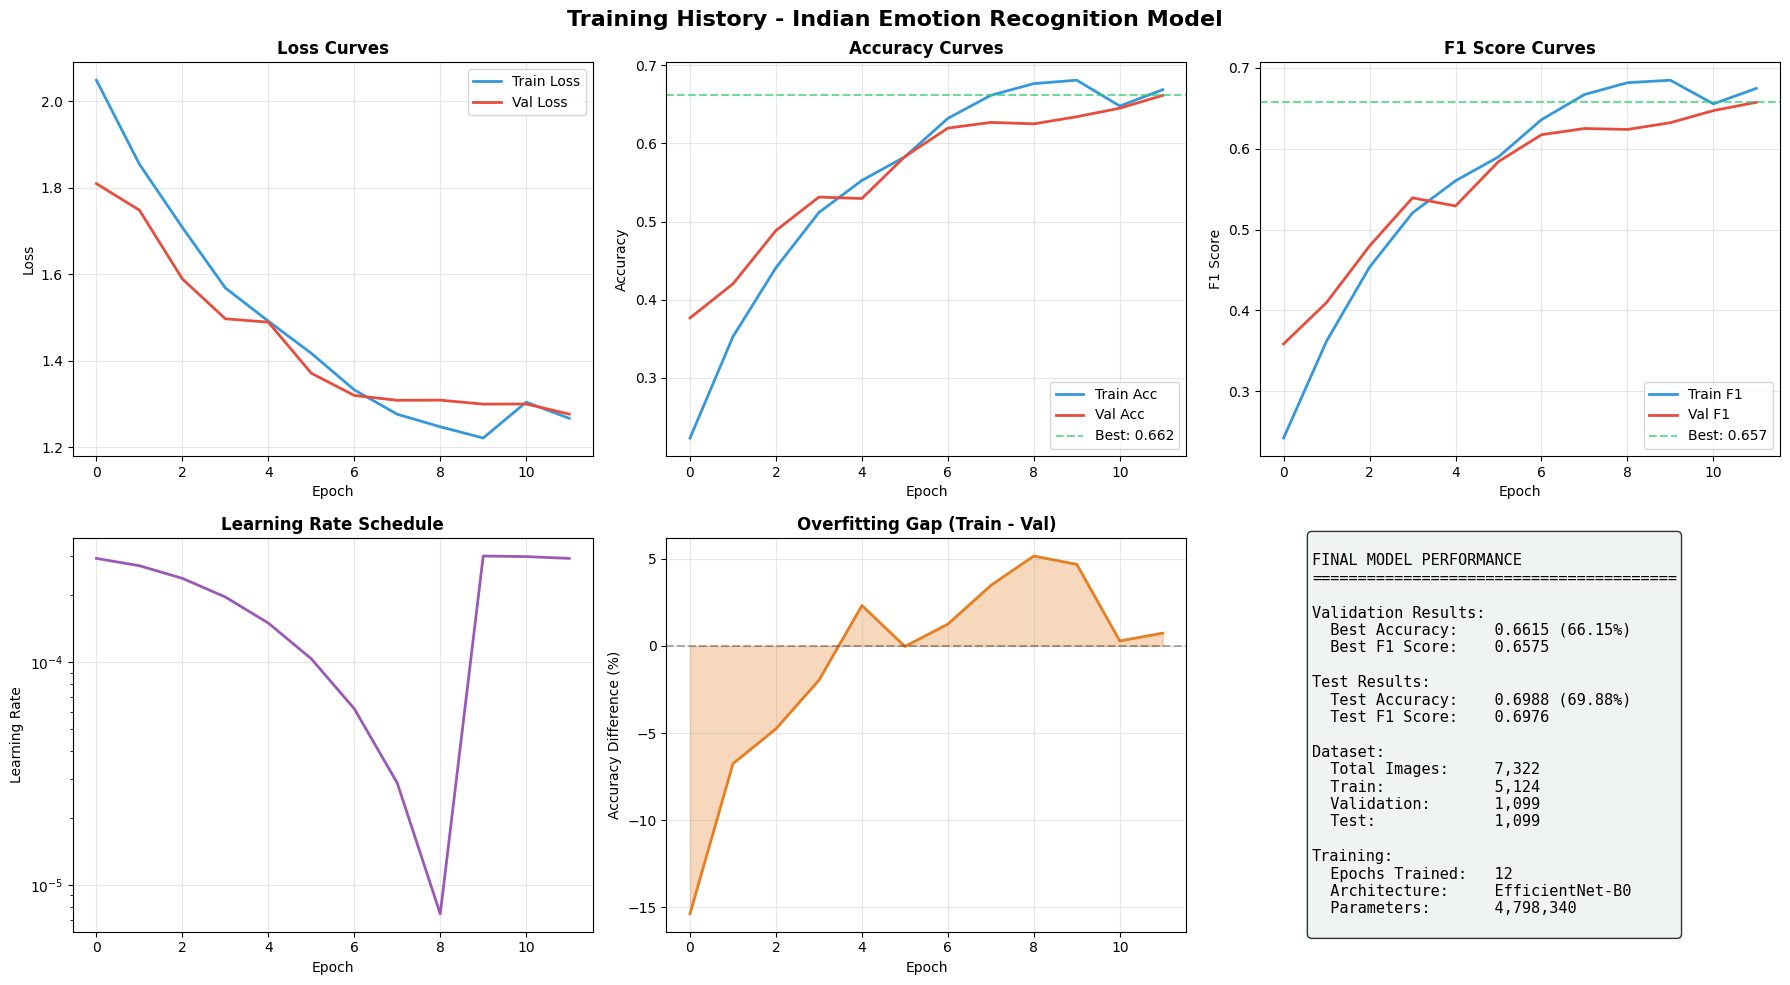

 Training history saved: indian_emotion_training_history.png


In [28]:
# ======================
# TRAINING HISTORY VISUALIZATION
# ======================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training History - Indian Emotion Recognition Model', fontsize=16, fontweight='bold')

# Loss curves
axes[0, 0].plot(history['train_loss'], label='Train Loss', linewidth=2, color='#3498db')
axes[0, 0].plot(history['val_loss'], label='Val Loss', linewidth=2, color='#e74c3c')
axes[0, 0].set_title('Loss Curves', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy curves
axes[0, 1].plot(history['train_acc'], label='Train Acc', linewidth=2, color='#3498db')
axes[0, 1].plot(history['val_acc'], label='Val Acc', linewidth=2, color='#e74c3c')
axes[0, 1].axhline(y=best_val_acc, color='#2ecc71', linestyle='--', alpha=0.7, 
                   label=f'Best: {best_val_acc:.3f}')
axes[0, 1].set_title('Accuracy Curves', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# F1 Score curves
axes[0, 2].plot(history['train_f1'], label='Train F1', linewidth=2, color='#3498db')
axes[0, 2].plot(history['val_f1'], label='Val F1', linewidth=2, color='#e74c3c')
axes[0, 2].axhline(y=best_val_f1, color='#2ecc71', linestyle='--', alpha=0.7,
                   label=f'Best: {best_val_f1:.3f}')
axes[0, 2].set_title('F1 Score Curves', fontweight='bold')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('F1 Score')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Learning rate schedule
axes[1, 0].plot(history['lr'], linewidth=2, color='#9b59b6')
axes[1, 0].set_title('Learning Rate Schedule', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# Overfitting gap
gap = [(t - v) * 100 for t, v in zip(history['train_acc'], history['val_acc'])]
axes[1, 1].plot(gap, linewidth=2, color='#e67e22')
axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[1, 1].fill_between(range(len(gap)), gap, 0, alpha=0.3, color='#e67e22')
axes[1, 1].set_title('Overfitting Gap (Train - Val)', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy Difference (%)')
axes[1, 1].grid(True, alpha=0.3)

# Summary text
axes[1, 2].axis('off')
summary_text = f"""
FINAL MODEL PERFORMANCE
{'='*40}

Validation Results:
  Best Accuracy:    {best_val_acc:.4f} ({best_val_acc*100:.2f}%)
  Best F1 Score:    {best_val_f1:.4f}

Test Results:
  Test Accuracy:    {test_acc:.4f} ({test_acc*100:.2f}%)
  Test F1 Score:    {test_f1:.4f}

Dataset:
  Total Images:     {len(all_images):,}
  Train:            {len(train_images):,}
  Validation:       {len(val_images):,}
  Test:             {len(test_images):,}

Training:
  Epochs Trained:   {len(history['train_loss'])}
  Architecture:     EfficientNet-B0
  Parameters:       {total_params:,}
"""
axes[1, 2].text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center',
                family='monospace', bbox=dict(boxstyle='round', facecolor='#ecf0f1', alpha=0.8))

plt.tight_layout()
plt.savefig('indian_emotion_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Training history saved: indian_emotion_training_history.png")

In [29]:
# ======================
# COMPREHENSIVE SUMMARY & SAVE
# ======================

# Per-class performance
per_class_metrics = {}
for idx, emotion in enumerate(EMOTION_CLASSES):
    mask = [i for i, label in enumerate(test_labels_eval) if label == idx]
    if mask:
        class_preds = [test_preds[i] for i in mask]
        class_true = [test_labels_eval[i] for i in mask]
        class_acc = accuracy_score(class_true, class_preds)
        class_f1 = f1_score(class_true, class_preds, average='weighted')
        per_class_metrics[emotion] = {
            'accuracy': float(class_acc),
            'f1_score': float(class_f1),
            'test_samples': len(mask),
            'train_samples': Counter(train_labels)[idx]
        }

# Complete summary
summary = {
    'model_info': {
        'architecture': 'EfficientNet-B0 with Custom Classifier',
        'backbone': 'EfficientNet-B0 (ImageNet pretrained)',
        'total_parameters': total_params,
        'trainable_parameters': trainable_params,
        'model_size_mb': round(total_params * 4 / 1024 / 1024, 2)
    },
    'dataset_info': {
        'name': 'Dataset of Indian face images with various expressions',
        'total_images': len(all_images),
        'num_classes': NUM_CLASSES,
        'emotion_classes': EMOTION_CLASSES,
        'train_size': len(train_images),
        'val_size': len(val_images),
        'test_size': len(test_images),
        'class_distribution': dict(class_distribution),
        'imbalance_ratio': round(imbalance_ratio, 2)
    },
    'training_config': {
        'batch_size': BATCH_SIZE,
        'learning_rate': LR,
        'image_size': IMG_SIZE,
        'epochs_trained': len(history['train_loss']),
        'max_epochs': EPOCHS,
        'optimizer': 'AdamW',
        'scheduler': 'CosineAnnealingWarmRestarts',
        'loss_function': 'CrossEntropyLoss (weighted + label smoothing)',
        'early_stopping_patience': EARLY_STOPPING_PATIENCE,
        'mixed_precision': scaler is not None
    },
    'performance': {
        'validation': {
            'best_accuracy': float(best_val_acc),
            'best_f1_score': float(best_val_f1)
        },
        'test': {
            'accuracy': float(test_acc),
            'f1_score': float(test_f1)
        },
        'final_training': {
            'accuracy': float(history['train_acc'][-1]),
            'f1_score': float(history['train_f1'][-1])
        },
        'overfitting_gap': float(history['train_acc'][-1] - history['val_acc'][-1])
    },
    'per_class_performance': per_class_metrics
}

# Save summary
summary_path = 'indian_emotion_model_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*80)
print(" COMPREHENSIVE SUMMARY")
print("="*80)

print("\n  MODEL ARCHITECTURE:")
print(f"   Architecture:         {summary['model_info']['architecture']}")
print(f"   Total Parameters:     {summary['model_info']['total_parameters']:,}")
print(f"   Model Size:           {summary['model_info']['model_size_mb']:.1f} MB")

print("\n DATASET:")
print(f"   Name:                 {summary['dataset_info']['name']}")
print(f"   Total Images:         {summary['dataset_info']['total_images']:,}")
print(f"   Classes:              {summary['dataset_info']['num_classes']}")
print(f"   Train/Val/Test:       {len(train_images)}/{len(val_images)}/{len(test_images)}")
print(f"   Imbalance Ratio:      {summary['dataset_info']['imbalance_ratio']}x")

print("\n  TRAINING:")
print(f"   Epochs Trained:       {summary['training_config']['epochs_trained']}/{EPOCHS}")
print(f"   Optimizer:            {summary['training_config']['optimizer']}")
print(f"   Mixed Precision:      {'Yes' if summary['training_config']['mixed_precision'] else 'No'}")

print("\n PERFORMANCE:")
print(f"   Val Accuracy:         {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"   Val F1 Score:         {best_val_f1:.4f}")
print(f"   Test Accuracy:        {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   Test F1 Score:        {test_f1:.4f}")

print("\n PER-CLASS TEST PERFORMANCE:")
for emotion in EMOTION_CLASSES:
    if emotion in per_class_metrics:
        metrics = per_class_metrics[emotion]
        acc = metrics['accuracy']
        bar = '█' * int(acc * 50)
        print(f"   {emotion:12} : {acc:6.2%} ({metrics['test_samples']:3} test samples) {bar}")

print("\n" + "="*80)
print(f" Summary saved to: {summary_path}")
print(f" Model saved to: {SAVE_PATH}")
print("="*80)


 COMPREHENSIVE SUMMARY

  MODEL ARCHITECTURE:
   Architecture:         EfficientNet-B0 with Custom Classifier
   Total Parameters:     4,798,340
   Model Size:           18.3 MB

 DATASET:
   Name:                 Dataset of Indian face images with various expressions
   Total Images:         7,322
   Classes:              8
   Train/Val/Test:       5124/1099/1099
   Imbalance Ratio:      3.5x

  TRAINING:
   Epochs Trained:       12/12
   Optimizer:            AdamW
   Mixed Precision:      No

 PERFORMANCE:
   Val Accuracy:         0.6615 (66.15%)
   Val F1 Score:         0.6575
   Test Accuracy:        0.6988 (69.88%)
   Test F1 Score:        0.6976

 PER-CLASS TEST PERFORMANCE:
   Anger        : 54.22% (225 test samples) ███████████████████████████
   Confused     : 76.14% (176 test samples) ██████████████████████████████████████
   Excited      : 63.08% ( 65 test samples) ███████████████████████████████
   Fear         : 69.57% ( 69 test samples) █████████████████████████████████